# Preprocessing and descriptive statistics 
In this project, I try to assess the complexity level of central bank speeches, focusing on three central banks : the ECB, the Fed and the BoE. To do so, I rely on a dataset of speeches from these three institutions. This dataset comes from this article : Campiglio, E., Deyris, J., Romelli, D. and Scalisi, G., 2025. Warning words in a warming world: Central bank communication and climate change. European Economic Review [Open Access], Vol 178.

### Importation of the data

In [1]:
import sys
sys.path.append('/home/onyxia/work/nlp_central_banks/lyna_work')

from module import *

In [20]:
# Database of Campiglio, Deyris, Romelli and Scalisi (saved in the SSP Cloud, too heavy for github) :
MY_BUCKET = "lelkamel"
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)
files_url = f"{MY_BUCKET}/"
fs.get(f"{MY_BUCKET}/","", recursive=True)

#Import
specialized_speeches = pd.read_csv("CBS_dataset_v1.0.csv")

### Checking the data and selecting the subsample of interest
In this part, I start by selecting the sample that interests me, that is, speeches from the BoE, the Fed and the ECB starting 2001.

In [21]:
#I start my analysis in 2001
specialized_speeches["Date"] = pd.to_datetime(specialized_speeches["Date"])
specialized_speeches["Year"] = specialized_speeches["Date"].dt.year
specialized_speeches = specialized_speeches[specialized_speeches["Year"] > 2000]

# I only select the Fed, the BoE and the ECB
countries_selected = [
    "USA",
    "GBR",
    "ECB"
]
specialized_speeches = specialized_speeches[
    specialized_speeches["Country"].isin(countries_selected)
]

selected_banks = [
    "Bank of England",
    "Board of Governors of the Federal Reserve",
    "European Central Bank"
]
specialized_speeches_filtered = specialized_speeches[specialized_speeches["CentralBank"].isin(selected_banks)].copy()

In [34]:
df_topic = specialized_speeches_filtered.copy()
df_topic.head(3)

,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,text,text_original,Filename,Language,Source,Year
3049,https://www.ecb.europa.eu/press/key/date/2001/...,NaN,Lessons from the European experience with exch...,"Speech delivered by Christian Noyer, Vice...",2001-01-14,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,Lessons from the European experience with exch...,NaN,ecb_010114.en,English,BIS,2001
3050,https://www.ecb.europa.eu/press/key/date/2001/...,NaN,Some ECB views on the accession process,"Speech delivered by Christian Noyer, Vice-Pre...",2001-01-17,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,Some ECB views on the accession process Speech...,NaN,ecb_010117.en,English,BIS,2001
3051,https://www.ecb.europa.eu/press/key/date/2001/...,NaN,L'euro et l'volution du paysage financier en E...,"Allocution prononce par Christian Noyer, V...",2001-01-19,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The euro and the changing financial landscape ...,NaN,ecb_010119.en,English,CB websites,2001


The dataset contains the following columns : 
- `URL` : the URL address of the speech, if collected from a website
- `PDF` : the address of the PDF file
- `Title` : the title of the speech
- `Subtitle` : the subtitle of the speech, when available
- `Date` : the date of the speech
- `Authorname` : the full name of the speaker
- `Role` : the institutional role of the speaker, coded as `Governor`, 
  `Deputy Governor`, `Board member`, or `Senior management`
- `Gender` : the gender of the speaker, coded as `Male` or `Female`
- `CentralBank` : the institution of the speaker
- `Country` : the country of the central bank
- `text` : the full text of the speech, translated to English when necessary
- `text_original` : the original text of the speech, when it was not in English
- `Filename` : the filename of the source document
- `Language` : the original language of the speech
- `Source` : the data source, coded as `BIS`, `CB websites`, or `Archives`
- `Year` : the year of the speech

I check whether there are missing observations. There don't seem to be any for the most important variables : (i) text, (ii) centralbank (iii) Role, (iv) Country, (v) Source, (vi) Date.

In [23]:
df_topic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5340 entries, 3049 to 35479
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   URL            5340 non-null   object        
 1   PDF            2790 non-null   object        
 2   Title          5340 non-null   object        
 3   Subtitle       4776 non-null   object        
 4   Date           5340 non-null   datetime64[ns]
 5   Authorname     5340 non-null   object        
 6   Role           5340 non-null   object        
 7   Gender         5340 non-null   object        
 8   CentralBank    5340 non-null   object        
 9   Country        5340 non-null   object        
 10  text           5340 non-null   object        
 11  text_original  121 non-null    object        
 12  Filename       5340 non-null   object        
 13  Language       5340 non-null   object        
 14  Source         5340 non-null   object        
 15  Year           5340 no

### Correcting artifacts to prepare the data for NLP tasks
In this part, I make sure the text is well formated. I look and correct serveral artifacts. 

In [24]:
# --- First, I do some verifications to see how speeches are formatted ---
print(df_topic['Language'].value_counts())
mask = df_topic['text_original'].notna()
print(df_topic[mask][['text', 'text_original']].head(2)) 

Language
English    5219
German       76
Spanish      28
French       12
Italian       5
Name: count, dtype: int64
                                                   text  \
3063  Inflation, a key variable for the ECB's moneta...   
3065  Europe and the new economy Eugenio Domingo Sol...   

                                          text_original  
3063  La inflacin, una variable clave para la poltic...  
3065  Europa y la nueva economa Eugenio Domingo Sola...  


 As expected, some speeches are not in English. For example, there are speeches in German, French, Italian. These must be ECB speeches. However, the good news is, that at said in Campiglio, all texts were translated in English !

In [25]:
#By analysing a speech which was a PDF on an LLM, I see that it still has PDF page numbers in the “1/2001” format 
#  how widely can we find some in the dataset ? 
print(df_topic.groupby(['Source', df_topic['PDF'].notna()])['text'].apply(
    lambda x: x.str.contains(r'\d{1,2}/\d{4}\s+\d+', regex=True, na=False).mean()
).round(2))

Source       PDF  
Archives     True     0.00
BIS          False    0.00
             True     0.39
CB websites  False    0.00
             True     0.01
Name: text, dtype: float64


I also look for some artifacts in PDFs, for example here it seems that the page numbers in format "1/2001" are specific to BIS documents. I generalise this reasoning and use the metadata to look for common pattern in order to better clean it in a function that will rely on a dictionnary.

In [26]:
# With the help of an LLM (Claude ai), I write this code to check more systematically for other recurrent patterns
patterns = {
    'footer_ECB':     r'CONTACT European Central Bank',
    'footer_BOE':     r'Bank of England.*?©',
    'footer_FED':     r'Federal Reserve.*?Board',
    'page_number':    r'\b\d{1,2}/\d{4}\b',
    'encoding_artefact': r'[A-Za-z]\d[A-Za-z]\d',  # "Rf6ntgen"
    'references':     r'\b(References|Bibliography)\b',
    'tables':         r'(Table \d|Figure \d)',
    'footnotes':      r'^\d{1,2}\.',          # lignes commençant par "1."
    'urls':           r'https?://\S+',
    'brackets_ref':   r'\(\w+,\s*\d{4}\)',    # "(Nickell, 1997)"
    'squarebrackets': r'\[\d+\]',             # "[1]"
}

for name, pat in patterns.items():
    count = df_topic['text'].str.contains(pat, regex=True, na=False).sum()
    pct = count / len(df_topic) * 100
    print(f"{name:25s} : {count:4d} discours ({pct:.1f}%)")


footer_ECB                : 2097 discours (39.3%)
footer_BOE                :    0 discours (0.0%)
footer_FED                : 1602 discours (30.0%)
page_number               :  860 discours (16.1%)
encoding_artefact         :   65 discours (1.2%)


/tmp/ipykernel_132906/3848981163.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df_topic['text'].str.contains(pat, regex=True, na=False).sum()


references                :  747 discours (14.0%)
tables                    :  512 discours (9.6%)
footnotes                 :    0 discours (0.0%)
urls                      :    1 discours (0.0%)
brackets_ref              :  337 discours (6.3%)
squarebrackets            : 1537 discours (28.8%)


Note that some speech have a reference section ! We will have to remove them to for the topic modelling to work well. 

In [27]:
# ── References section ─────────────────────────────────────
print("\n=== Speeches with References section ===")
has_refs = df_topic['text'].str.contains(r'\b(References|Bibliography)\b', regex=True, na=False)
sample_ref = df_topic[has_refs]['text'].iloc[0]
match = re.search(r'\b(References|Bibliography)\b', sample_ref)
print(repr(sample_ref[max(0, match.start()-100):match.end()+300]))


=== Speeches with References section ===


/tmp/ipykernel_132906/2963717491.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_refs = df_topic['text'].str.contains(r'\b(References|Bibliography)\b', regex=True, na=False)


'in this "revolution" by ensuring the enabling factor of price stability. Annex: [pdf, 94kb] List of References Barber, W. J. (ed.) (1977), "The Works of I. Fisher", Pickering and Chatto. Bassanini, A., S. Scarpetta and I. Visco (2000), "Knowledge, technology and economic growth: recent evidence from OECD countries", mimeo, OECD, Paris , May. Bordo, M., B. Eichengreen and I. Douglas (1999), "Is Globalization'


Thanks to this initial exploratory work, I now have enough data to write a database cleanup function tailored to the different text formats. Before moving on to this step, I also examine the distribution of text lengths by central bank and by role to ensure there are no anomalies. I want to understand more why some speeches have a reference section.

###  Checking the lenght distribution of the speeches

In [35]:
# Compare average length by role and bank
df_topic['n_words'] = df_topic['text'].str.split().str.len()
print("=== Average speech length by role and central bank ===\n")
print(
    df_topic.groupby(['CentralBank', 'Role'])['n_words']
    .agg(['count', 'mean', 'max'])
    .round(0)
    .sort_values('mean', ascending=False)
    .to_string()
)

print()

=== Average speech length by role and central bank ===

                                                             count    mean    max
CentralBank                               Role                                   
Bank of England                           Board member         391  6230.0  26285
                                          Deputy Governor      283  4320.0  19475
                                          Senior management    383  3824.0  13625
                                          Governor             190  3568.0  12119
Board of Governors of the Federal Reserve Board member         841  3434.0  14204
                                          Deputy Governor      320  3342.0   9599
European Central Bank                     Deputy Governor      308  3313.0  11360
                                          Board member        1420  3139.0  12957
Board of Governors of the Federal Reserve Senior management     19  3053.0   7176
                                          

A closer inspection of the longest speeches in the corpus reveals an important  heterogeneity in the Bank of England sample. Unlike the ECB and the Federal Reserve, whose communications are predominantly policy speeches, the Bank of England corpus includes a significant number of speeches that are closer to **academic working papers** than to traditional central bank communication. 

A striking example is the speech by Stephen Nickell — MPC member and Professor at the London School of Economics — entitled *"A Picture of European Unemployment: Success and Failure"* (2002), which was prepared for an academic conference organised by the Yrjö Jahnsson Foundation and CESifo. This document features a full academic structure: numbered sections, 25+ statistical tables, 30+ bibliographic references, and acknowledgements to research assistants — making it virtually indistinguishable from a working paper.

In [36]:
# ── Illustrate the Nickell case ────────────────────────────
nickell = df_topic[df_topic['Authorname'].str.contains('Nickell', na=False)].iloc[0]

print("=== Example of an academic-style BoE speech ===\n")
print(f"Author  : {nickell['Authorname']}")
print(f"Role    : {nickell['Role']}")
print(f"Year    : {nickell['Year']}")
print(f"Words   : {nickell['n_words']}")
print(f"Source  : {nickell['Source']}")
print()

# Count tables, references, citations
text = nickell['text']
n_tables    = len(re.findall(r'Table \d+', text))
n_figures   = len(re.findall(r'Figure \d+', text))
n_citations = len(re.findall(r'\(\w+,\s*\d{4}\)', text))
has_refs    = bool(re.search(r'\bReferences\b', text))

print(f"Tables found       : {n_tables}")
print(f"Figures found      : {n_figures}")
print(f"In-text citations  : {n_citations}")
print(f"References section : {has_refs}")

print("=== Reference to tables found ===")
table_matches = list(re.finditer(r'Table \d+', text))
for m in table_matches[:3]:
    print(repr(text[max(0, m.start()-100):m.end()+200]))
    print("---")

print("\n=== Reference to figures found ===")
figure_matches = list(re.finditer(r'Figure \d+', text))
for m in figure_matches[:3]:
    print(repr(text[max(0, m.start()-100):m.end()+200]))
    print("---")

print("\n=== In-text citations ===")
citation_matches = list(re.finditer(r'\(\w+,\s*\d{4}\)', text))
for m in citation_matches[:3]:
    print(repr(text[max(0, m.start()-100):m.end()+100]))
    print("---")

print("\n=== References section ===")
ref_match = re.search(r'\bReferences\b', text)
if ref_match:
    print(repr(text[ref_match.start():ref_match.start()+500]))

=== Example of an academic-style BoE speech ===

Author  : Stephen Nickell
Role    : Board member
Year    : 2002
Words   : 15039
Source  : CB websites

Tables found       : 53
Figures found      : 5
In-text citations  : 1
References section : True
=== Reference to tables found ===
'helpful to look at some more general background information on various aspects of labour supply. In Table 1, we present the aggregate picture in 2001 and 2002. Taking the very latest unemployment data, the first striking point, which we have already noted, 2 that there is not a European unemployment proble'
---
'cond point worth noting is the pattern of long-term unemployment rates (over 12 months), set out in Table 2. Here we see that while the short-term unemployment rate in the European Union is relatively low at 4.3%, the long-term rate far exceeds that outside Europe. The Big Four and Belgium all have long-te'
---
' changes such a lot over time, we start with a general picture of the period from 1960 pr

To address this heterogeneity and ensure **comparability across institutions**, I restrict the analysis to speeches delivered by **Governors and Deputy Governors only**. These positions are strictly comparable across the three institutions and exclude external academic appointments  such as MPC members, whose communication style may differ substantially from that of the institution's leadership. I start by cleaning the text, following the patterns seen previously.

In [46]:
#I consider only Governor and Deputy governor's texts.
df_filtered = df_topic[df_topic['Role'].isin(['Governor', 'Deputy Governor'])].copy()

In [47]:
# In this chunk, I apply a cleaning function I built that account for all patterns mentioned above
df_filtered['text_clean'] = df_filtered.apply(clean_text, axis=1)
df_filtered['n_words_clean'] = df_filtered['text_clean'].str.split().str.len()

diff = df_filtered['n_words'] - df_filtered['n_words_clean']

print(diff.describe().round(1))
print(f"\nDiscours avec au moins 1 mot nettoyé    : {(diff > 0).sum()}")
print(f"Discours avec > 200 mots nettoyés       : {(diff > 200).sum()}")
print(f"Discours avec > 500 mots nettoyés       : {(diff > 500).sum()}")
print(f"Discours avec > 1000 mots nettoyés      : {(diff > 1000).sum()}")
print(f"Discours avec > 2000 mots nettoyés      : {(diff > 2000).sum()}")

print(f"\nAucun discours n'est éliminé — tous les {len(df_filtered)} discours sont conservés")
print(f"Réduction moyenne du texte : {diff.mean():.0f} mots ({diff.mean()/df_filtered['n_words'].mean()*100:.1f}%)")

count    2286.0
mean       61.5
std       203.4
min         0.0
25%         0.0
50%         8.0
75%        17.0
max      1923.0
dtype: float64

Discours avec au moins 1 mot nettoyé    : 1426
Discours avec > 200 mots nettoyés       : 176
Discours avec > 500 mots nettoyés       : 99
Discours avec > 1000 mots nettoyés      : 35
Discours avec > 2000 mots nettoyés      : 0

Aucun discours n'est éliminé — tous les 2286 discours sont conservés
Réduction moyenne du texte : 62 mots (1.9%)


In [48]:
# Show the difference after filtering
print("=== Average length : full sample vs. filtered sample ===\n")
full_sample = df_topic.groupby('CentralBank')['n_words'].agg(['mean', 'max', 'min']).round(0)
filtered_sample = df_filtered.groupby('CentralBank')['n_words'].agg(['mean', 'max', 'min']).round(0)

comparison = pd.concat(
    {
        'Full sample': full_sample,
        'Gov. & Deputy Gov.': filtered_sample
    },
    axis=1
).sort_values(('Full sample', 'mean'), ascending=False)
print(comparison)

=== Average length : full sample vs. filtered sample ===

                                          Full sample              \
                                                 mean    max  min   
CentralBank                                                         
Bank of England                                4652.0  26285  254   
Board of Governors of the Federal Reserve      3221.0  14204  228   
European Central Bank                          3039.0  15010  213   

                                          Gov. & Deputy Gov.              
                                                        mean    max  min  
CentralBank                                                               
Bank of England                                       4018.0  19475  423  
Board of Governors of the Federal Reserve             3006.0  13163  228  
European Central Bank                                 2897.0  15010  213  


Restricting to Governors and Deputy Governors reduces average speech length and ensures comparability across the three institutions. However, we can see that the texts remain on average very long and are heterogeneous. We will dill with this later in the preprocessing for topic modelling part.

### Some descriptive statistics

#### General figures on the dataset

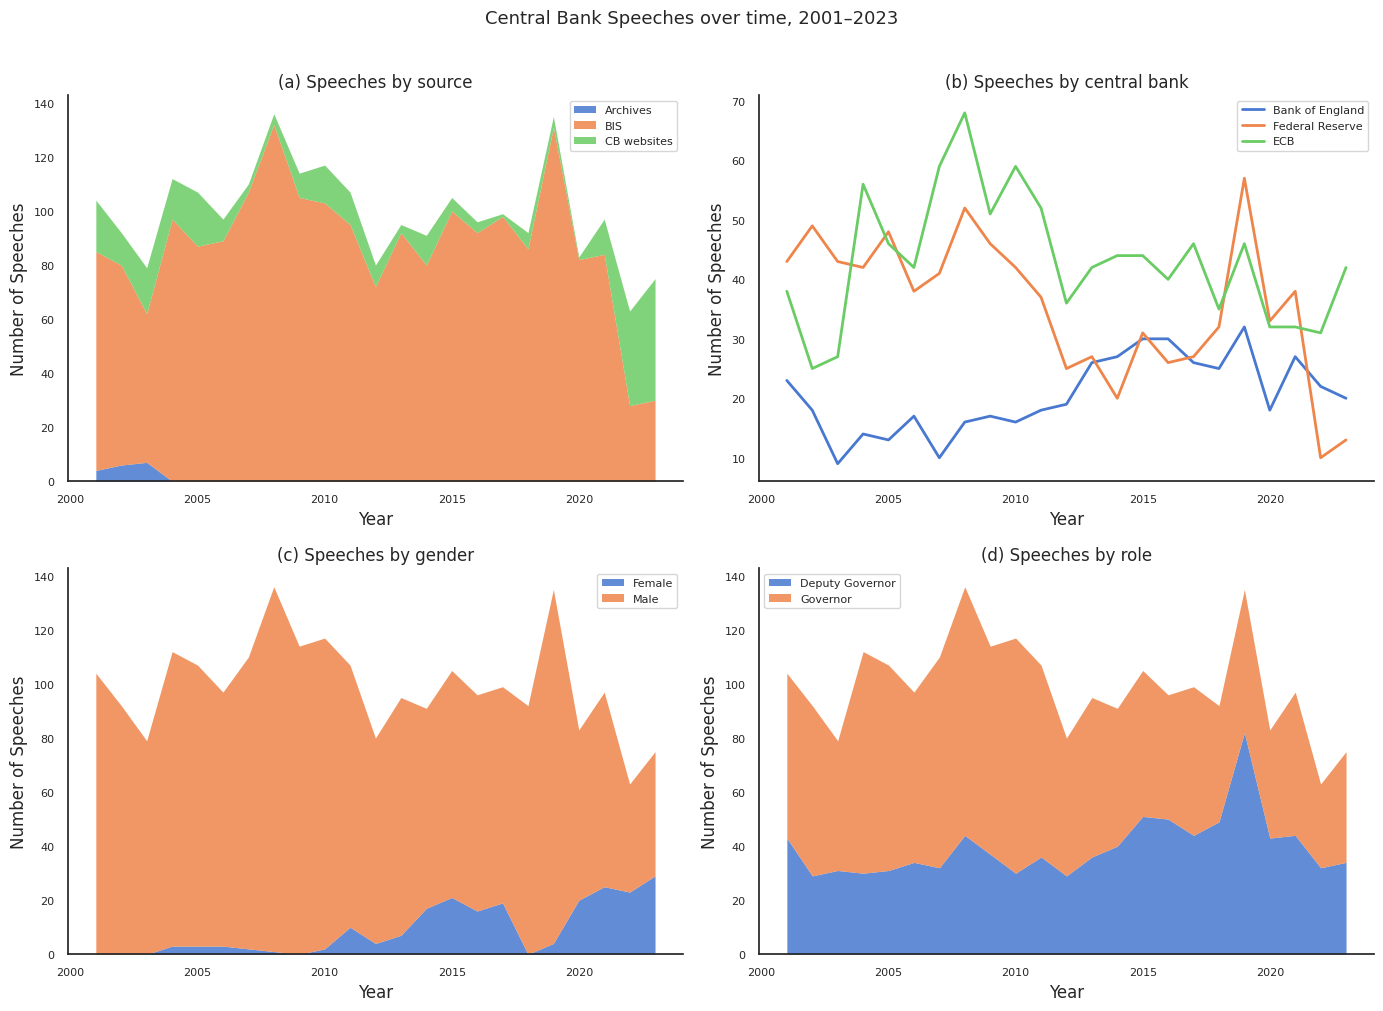

In [49]:
# Setup
sns.set_theme(style="white", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Central Bank Speeches over time, 2001–2023", fontsize=13, y=1.01)

# ── (a) Speeches by Source ─────────────────────────────────
pivot_source = (
    df_filtered.groupby(['Year', 'Source'])
    .size().reset_index(name='count')
    .pivot(index='Year', columns='Source', values='count')
    .fillna(0)
)
pivot_source.plot.area(ax=axes[0,0], alpha=0.85, linewidth=0)
axes[0,0].set_title("(a) Speeches by source")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Number of Speeches")
axes[0,0].legend(title="", fontsize=8)

# ── (b) Speeches by Central Bank ──────────────────────────
pivot_bank = (
    df_filtered.groupby(['Year', 'CentralBank'])
    .size().reset_index(name='count')
)
# Raccourcir les noms
pivot_bank['CentralBank'] = pivot_bank['CentralBank'].replace({
    'Board of Governors of the Federal Reserve': 'Federal Reserve',
    'European Central Bank': 'ECB',
    'Bank of England': 'Bank of England'
})
sns.lineplot(
    data=pivot_bank, x='Year', y='count',
    hue='CentralBank', ax=axes[0,1], linewidth=2
)
axes[0,1].set_title("(b) Speeches by central bank")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Number of Speeches")
axes[0,1].legend(title="", fontsize=8)

# ── (c) Speeches by Gender ─────────────────────────────────
pivot_gender = (
    df_filtered.groupby(['Year', 'Gender'])
    .size().reset_index(name='count')
    .pivot(index='Year', columns='Gender', values='count')
    .fillna(0)
)
pivot_gender.plot.area(ax=axes[1,0], alpha=0.85, linewidth=0)
axes[1,0].set_title("(c) Speeches by gender")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Number of Speeches")
axes[1,0].legend(title="", fontsize=8)

# ── (d) Speeches by Role ───────────────────────────────────
pivot_role = (
    df_filtered.groupby(['Year', 'Role'])
    .size().reset_index(name='count')
    .pivot(index='Year', columns='Role', values='count')
    .fillna(0)
)
pivot_role.plot.area(ax=axes[1,1], alpha=0.85, linewidth=0)
axes[1,1].set_title("(d) Speeches by role")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("Number of Speeches")
axes[1,1].legend(title="", fontsize=8)

# ── Finitions ──────────────────────────────────────────────
for ax in axes.flat:
    sns.despine(ax=ax)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

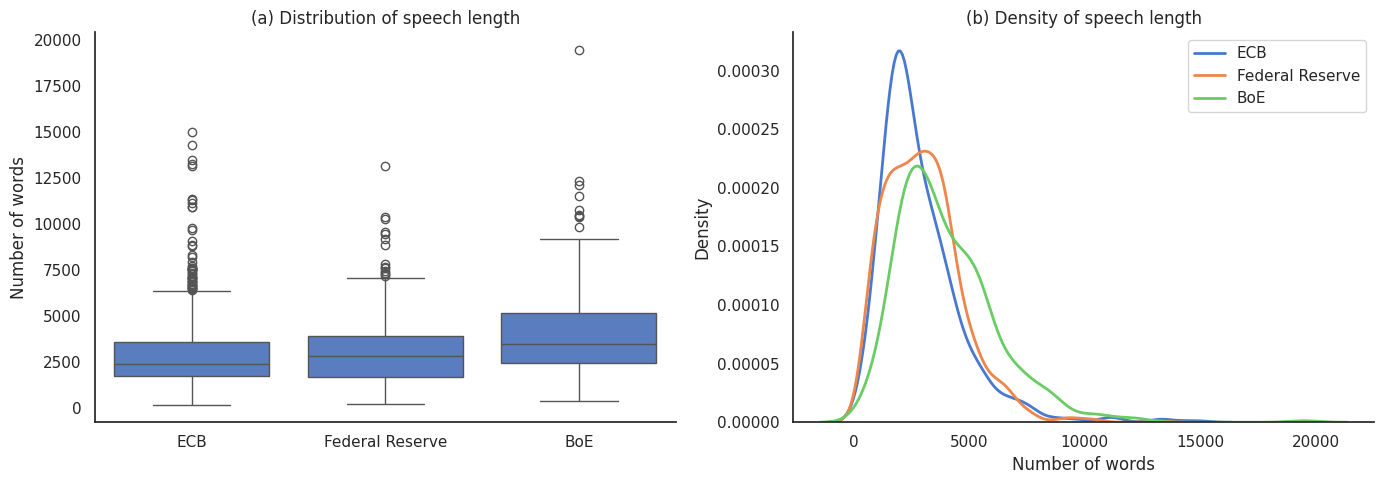

In [52]:
sns.set_theme(style="white", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raccourcir les noms
df_filtered['CB_short'] = df_filtered['CentralBank'].replace({
    'Board of Governors of the Federal Reserve': 'Federal Reserve',
    'European Central Bank': 'ECB',
    'Bank of England': 'BoE'
})

# ── (a) Boxplot ────────────────────────────────────────────
sns.boxplot(
    data=df_filtered,
    x='CB_short', y='n_words',
    ax=axes[0],
    order=['ECB', 'Federal Reserve', 'BoE']
)
axes[0].set_title("(a) Distribution of speech length")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of words")

# ── (b) KDE ────────────────────────────────────────────────
for bank in ['ECB', 'Federal Reserve', 'BoE']:
    subset = df_filtered[df_filtered['CB_short'] == bank]['n_words']
    sns.kdeplot(subset, ax=axes[1], label=bank, linewidth=2)

axes[1].set_title("(b) Density of speech length")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Density")
axes[1].legend(title="")

for ax in axes:
    sns.despine(ax=ax)

#plt.suptitle("Speech length by central bank — Governors & Deputy Governors, 2001–2023",
#             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

#### Some descriptive statistics on the text's complexity

We consider several metrics that aim to capture the **cognitive complexity** of texts—such as sentence length, document length, and grammatical structure.

However, as highlighted in a *June 2025 International Monetary Fund working paper*, these indicators, while informative, **do not fully capture the semantic content of communication**, including the underlying economic rationale, policy intent, or strategic framing. 
To deliver some insight on this question, we focus on the following metrics:

1. **Average word count by institution**  
   Measures the typical length of documents and provides a proxy for the overall verbosity of communication.

2. **Average sentence length**  
   Captures syntactic complexity at the sentence level, with longer sentences generally indicating higher processing effort.

3. **Flesch–Kincaid score**  
   Evaluates readability and linguistic difficulty based on sentence length and word complexity.

4. **Dependency depth by institution**  
   Reflects grammatical complexity by measuring the depth of syntactic dependency trees.

These metrics provide a useful first layer of analysis for comparing communication styles across institutions, but remain limited to surface-level textual features.

In [ ]:
import numpy as np
from textstat import flesch_reading_ease
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt_tab')

In [ ]:
#Varable to study speech complexity (6 minutes)
df['word_count'] = df['text'].apply(lambda x: len(word_tokenize(x))) 
df['char_count'] = df['text'].apply(len)
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))
df['avg_word_length'] = df['text'].apply(lambda x: np.mean([len(word) for word in word_tokenize(x)]) if len(word_tokenize(x)) > 0 else 0)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count']
df['flesch_score'] = df['text'].apply(lambda x: flesch_reading_ease(x))

In [ ]:
figures_path = "/home/onyxia/work/nlp_central_banks/lyna_work/figures"
os.makedirs(figures_path, exist_ok=True)

countries = ['ECB', 'GBR', 'USA']
labels = {'ECB': 'ECB', 'GBR': 'BoE', 'USA': 'FED'}

df_plot = df[df['Country'].isin(countries)].copy()
df_plot['Institution'] = df_plot['Country'].map(labels)
df_plot['Year'] = df_plot['Year'].astype(int)

yearly = (
    df_plot
    .groupby(['Institution', 'Year'])
    .agg({
        'word_count': 'mean',
        'avg_sentence_length': 'mean',
        'flesch_score': 'mean',
        'dependency_depth': 'mean'
    })
    .reset_index()
)
metrics_1 = ['word_count', 'avg_sentence_length']
titles_1 = ['Word Count', 'Average Sentence Length']

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

for i, (metric, title) in enumerate(zip(metrics_1, titles_1)):
    sns.boxplot(
        data=df_plot,
        x='Institution',
        y=metric,
        ax=axs[0, i]
    )
    axs[0, i].set_title(f'{title} by Institution')
    axs[0, i].grid(True, alpha=0.3)

    for inst in ['ECB', 'BoE', 'FED']:
        inst_data = yearly[yearly['Institution'] == inst]
        axs[1, i].plot(
            inst_data['Year'],
            inst_data[metric],
            marker='o',
            linewidth=2,
            label=inst
        )

    axs[1, i].set_title(f'{title} Over Time')
    axs[1, i].set_xlabel('Year')
    axs[1, i].set_ylabel(title)
    axs[1, i].grid(True, alpha=0.3)
    axs[1, i].legend()

plt.tight_layout()
plt.savefig(
    f"{figures_path}/speech_complexity_word_sentence_length.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
from tqdm import tqdm
import pydantic
import spacy
import thinc

print("pydantic:", pydantic.__version__)
print("spacy:", spacy.__version__)
print("thinc:", thinc.__version__)

nlp = spacy.load("en_core_web_sm")
print("OK")


# -----------------------------
# 3. Function to compute dependency depth of one sentence
# -----------------------------
def sentence_dependency_depth(sent):
    """
    Depth = longest path from sentence root to any terminal node (leaf).
    We count nodes on the path, so a root->child->grandchild path has depth 3.
    """
    root = sent.root

    def depth_from_token(token):
        children = list(token.children)
        if not children:
            return 1
        return 1 + max(depth_from_token(child) for child in children)

    return depth_from_token(root)

# -----------------------------
# 4. Function to compute speech-level dependency depth
# -----------------------------
def speech_dependency_depth(text):
    """
    Compute average sentence dependency depth for one speech.
    You could also use max(sentence depths) instead of mean if preferred.
    """
    doc = nlp(text)

    sentence_depths = []
    for sent in doc.sents:
        # skip extremely short / empty-like sentences
        sent_tokens = [tok for tok in sent if not tok.is_space]
        if len(sent_tokens) == 0:
            continue
        sentence_depths.append(sentence_dependency_depth(sent))

    if len(sentence_depths) == 0:
        return None

    return sum(sentence_depths) / len(sentence_depths)

#df['dependency_depth'] = df['text'].apply(speech_dependency_depth)
# Drop rows where parsing failed
#df = df.dropna(subset=['dependency_depth'])


output_file = "df_with_depth.csv"

# Reprise si fichier existe
if os.path.exists(output_file):
    df_saved = pd.read_csv(output_file)
    df['dependency_depth'] = df_saved['dependency_depth']
else:
    df['dependency_depth'] = None

# Boucle avec barre de progression
for i in tqdm(range(len(df)), desc="Processing speeches"):
    
    if pd.notnull(df.loc[i, 'dependency_depth']):
        continue  # skip déjà fait

    text = df.loc[i, 'text']
    
    try:
        depth = speech_dependency_depth(text)
    except Exception as e:
        depth = None
        print(f"\nError at index {i}: {e}")  # \n pour ne pas casser la barre

    df.loc[i, 'dependency_depth'] = depth

    # 💾 Sauvegarde tous les 10
    if i % 10 == 0:
        df.to_csv(output_file, index=False)

# Sauvegarde finale
df.to_csv(output_file, index=False)
print("Final save complete")

So the speeches seem to be shorter across time (except for the UK). Now, how readable are they ? I start to study leaxical readability metrics (such as the Flesch-Kincaid scores which are widely used over the literature). I also consider a grammatical metric, using dependency parsing (note that I do not use the most developed models, as we are only in a preprocessing step).

The Flesch-Kincaid Ease Score is calculated as:
$$
\text{Score } = 206.835-1.015(\frac{\text{ Total Words }}{\text{ Total Sentences }})-84.6(\frac{\text{ Total Syllables }}{\text{ Total Words }})
$$
The score ranges from 0 to 100, with higher values indicating better readability. In English-language texts, scores above 60 correspond to an 8th-grade reading level, while values between 30 and 50 suggest college-level complexity. Scores below 30 indicate highly technical or specialized content.

In [ ]:
df = pd.read_csv('/home/onyxia/work/nlp_central_banks/lyna_work/speeches_cleaned.csv')

In [ ]:
metrics_2 = ['flesch_score', 'dependency_depth']
titles_2 = ['Flesch/Kincaid Score', 'Dependency Depth']

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

for i, (metric, title) in enumerate(zip(metrics_2, titles_2)):
    sns.boxplot(
        data=df_plot,
        x='Institution',
        y=metric,
        ax=axs[0, i]
    )
    axs[0, i].set_title(f'{title} by Institution')
    axs[0, i].grid(True, alpha=0.3)

    for inst in ['ECB', 'BoE', 'FED']:
        inst_data = yearly[yearly['Institution'] == inst]
        axs[1, i].plot(
            inst_data['Year'],
            inst_data[metric],
            marker='o',
            linewidth=2,
            label=inst
        )

    axs[1, i].set_title(f'{title} Over Time')
    axs[1, i].set_xlabel('Year')
    axs[1, i].set_ylabel(title)
    axs[1, i].grid(True, alpha=0.3)
    axs[1, i].legend()

plt.tight_layout()
plt.savefig(
    f"{figures_path}/speech_complexity_flesch_dependency.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()